In [1]:
#MATEMATICA 3 UNSAM - TPI 

#TRABAJO PRACTICO FINAL
#Alumno: Alejandro Nava


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as seabornInstance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

dataset = pd.read_csv('video_juegos_populares.csv')

In [3]:
# Comentarios iniciales
# Entre todos los archivos de datos me llamo mas la atención el de videojuegos populares ya que era muy rico en informacion 
# y crei que seria sencillo de manipular los datos.
# PEnse en analizar como impactan las ventas en Estados Unidos con respecto a las ventas globales, para reflejar de alguna 
# manera que son la poblacion que consume mayor cantidad de videojuegos
# Ahora para no trabajar sobre absolutamente toda la base de datos decidi solo dedicarme a una empresa ddistribuidora
# y analizando los datos veo que Activision es la que realiza el juego con mas ventas
# Por lo tanto voy a crear otra dataset a partir del archivo birndado solo con las celdas que contengan Activision

In [4]:
# Analizo los datos

In [5]:
dataset.describe(include=['object'])

,Name,Platform,Genre,Publisher
count,7505,7505,7505,7501
unique,5777,12,12,353
top,Wipeout 2,DS,Action,Activision
freq,5,2131,1562,526


In [6]:
dataset.describe(include='all')

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,7505.000000,7505,7505,7505.000000,7505,7501,7505.000000,7505.000000,7505.000000,7505.000000,7505.000000
unique,NaN,5777,12,NaN,12,353,NaN,NaN,NaN,NaN,NaN
top,NaN,Wipeout 2,DS,NaN,Action,Activision,NaN,NaN,NaN,NaN,NaN
freq,NaN,5,2131,NaN,1562,526,NaN,NaN,NaN,NaN,NaN
mean,7762.459027,NaN,NaN,2007.401732,NaN,NaN,0.328866,0.169131,0.106576,0.053219,0.658099
std,4683.919028,NaN,NaN,6.236775,NaN,NaN,1.095222,0.654459,0.402491,0.192746,2.070870
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,3679.000000,NaN,NaN,2007.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.080000
50%,7638.000000,NaN,NaN,2009.000000,NaN,NaN,0.100000,0.010000,0.000000,0.010000,0.200000
75%,11637.000000,NaN,NaN,2011.000000,NaN,NaN,0.290000,0.120000,0.050000,0.040000,0.550000


In [7]:
# creo un nuevo dataset seleccionando unicamente las celdas que contengan Activision en la columna Publisher con la funcion loc

In [8]:
datasetAV = dataset.loc[dataset['Publisher'] == 'Activision']

In [9]:
# Analizo mi nuevo dataset

In [10]:
datasetAV.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
24,30,Call of Duty: Modern Warfare 3,X360,2011,Shooter,Activision,9.03,4.28,0.13,1.32,14.76
26,32,Call of Duty: Black Ops,X360,2010,Shooter,Activision,9.67,3.73,0.11,1.13,14.64
28,35,Call of Duty: Black Ops II,PS3,2012,Shooter,Activision,4.99,5.88,0.65,2.52,14.03
29,36,Call of Duty: Black Ops II,X360,2012,Shooter,Activision,8.25,4.30,0.07,1.12,13.73
30,37,Call of Duty: Modern Warfare 2,X360,2009,Shooter,Activision,8.52,3.63,0.08,1.29,13.51


In [11]:
datasetAV.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [12]:
# Grafico mis datos para ver si me eleccion fue buena... la verdad esperaba algo mejor pero estoy conforme, 
# creo que me sirve para trabajar

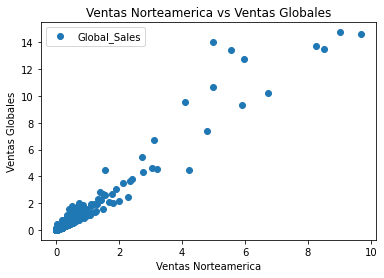

In [13]:
datasetAV.plot(x='NA_Sales', y='Global_Sales', style='o') 
plt.title('Ventas Norteamerica vs Ventas Globales') 
plt.xlabel('Ventas Norteamerica') 
plt.ylabel('Ventas Globales') 
plt.show()

In [14]:
# genero un pequeño grafico de los puntos de mi variable independiente

<Figure size 720x720 with 0 Axes>

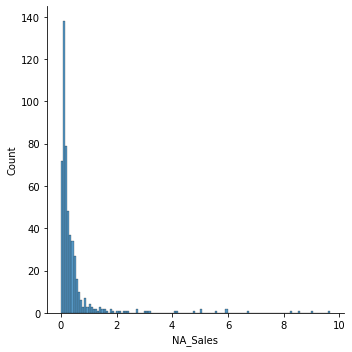

In [56]:
plt.figure(figsize=(10,10))
plt.tight_layout()
seabornInstance.displot(datasetAV['NA_Sales'])

In [16]:
# analizo con funciones de Panda la columna a cual corresponde NA_Sales
datasetAV.columns.get_loc('NA_Sales')

6

In [17]:
# creo los objetos de las variables
X = datasetAV.iloc[:,6].values
y = datasetAV.iloc[:,-1].values 

In [18]:
print(X)
print(y)

[9.03 9.67 4.99 8.25 8.52 5.54 5.98 4.99 6.72 4.09 5.91 4.79 3.1  2.72
 3.06 3.19 4.21 1.54 2.75 2.4  2.33 2.11 1.91 1.4  1.49 1.78 1.56 2.29
 1.32 1.4  1.42 2.01 1.68 0.71 1.81 1.2  1.3  1.1  0.85 0.49 1.11 0.67
 0.4  1.49 0.85 0.94 0.95 0.6  0.82 0.89 0.91 0.82 1.27 0.86 0.9  0.75
 0.84 1.22 1.04 0.56 1.12 0.65 1.   0.66 0.43 1.07 0.65 0.53 1.03 0.35
 0.43 0.96 0.44 0.56 0.42 0.62 0.68 0.48 0.6  0.73 0.53 0.39 0.41 0.7
 0.71 0.54 0.87 0.5  0.47 0.68 0.57 0.42 0.6  0.47 0.31 0.64 0.33 0.52
 0.48 0.33 0.51 0.47 0.72 0.59 0.41 0.47 0.36 0.43 0.31 0.42 0.49 0.22
 0.36 0.67 0.18 0.54 0.28 0.42 0.54 0.24 0.6  0.26 0.3  0.62 0.6  0.25
 0.46 0.3  0.28 0.49 0.49 0.38 0.58 0.54 0.34 0.58 0.46 0.58 0.33 0.51
 0.38 0.25 0.52 0.53 0.37 0.52 0.49 0.32 0.28 0.41 0.49 0.32 0.5  0.51
 0.41 0.52 0.51 0.32 0.43 0.28 0.21 0.25 0.33 0.24 0.47 0.47 0.41 0.29
 0.44 0.46 0.24 0.42 0.2  0.42 0.45 0.45 0.23 0.41 0.44 0.43 0.34 0.26
 0.24 0.42 0.42 0.03 0.3  0.42 0.26 0.27 0.41 0.21 0.36 0.28 0.4  0.4
 0.24 0.

In [26]:
# ajusto los valores para poder trabajarlos y predecir los datos
X = datasetAV['Global_Sales'].values.reshape(-1,1)
y = datasetAV['NA_Sales'].values.reshape(-1,1)

In [27]:
print(X)
print(y)

[[1.476e+01]
 [1.464e+01]
 [1.403e+01]
 [1.373e+01]
 [1.351e+01]
 [1.346e+01]
 [1.273e+01]
 [1.069e+01]
 [1.021e+01]
 [9.590e+00]
 [9.320e+00]
 [7.370e+00]
 [6.720e+00]
 [5.430e+00]
 [4.620e+00]
 [4.530e+00]
 [4.500e+00]
 [4.450e+00]
 [4.310e+00]
 [3.780e+00]
 [3.650e+00]
 [3.480e+00]
 [3.050e+00]
 [2.850e+00]
 [2.710e+00]
 [2.670e+00]
 [2.650e+00]
 [2.500e+00]
 [2.340e+00]
 [2.260e+00]
 [2.230e+00]
 [2.200e+00]
 [2.110e+00]
 [2.050e+00]
 [2.020e+00]
 [1.970e+00]
 [1.950e+00]
 [1.930e+00]
 [1.860e+00]
 [1.790e+00]
 [1.760e+00]
 [1.730e+00]
 [1.600e+00]
 [1.600e+00]
 [1.580e+00]
 [1.580e+00]
 [1.530e+00]
 [1.520e+00]
 [1.490e+00]
 [1.450e+00]
 [1.430e+00]
 [1.400e+00]
 [1.390e+00]
 [1.330e+00]
 [1.330e+00]
 [1.320e+00]
 [1.310e+00]
 [1.310e+00]
 [1.290e+00]
 [1.260e+00]
 [1.240e+00]
 [1.240e+00]
 [1.230e+00]
 [1.210e+00]
 [1.160e+00]
 [1.150e+00]
 [1.140e+00]
 [1.100e+00]
 [1.100e+00]
 [1.090e+00]
 [1.070e+00]
 [1.060e+00]
 [1.060e+00]
 [1.060e+00]
 [1.050e+00]
 [1.040e+00]
 [1.040e+00]

In [28]:
datasetAV.shape

(526, 11)

In [39]:
#analizo como queda mi DS
datasetAV.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000
mean,6300.171103,2008.254753,0.491407,0.214620,0.008118,0.080323,0.794601
std,3794.549197,6.387467,1.072398,0.635058,0.051419,0.227154,1.905534
min,30.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,3208.500000,2008.000000,0.110000,0.000000,0.000000,0.010000,0.142500
50%,6104.500000,2009.000000,0.200000,0.030000,0.000000,0.020000,0.285000
75%,9030.750000,2011.000000,0.420000,0.160000,0.000000,0.050000,0.630000
max,16414.000000,2016.000000,9.670000,5.880000,0.650000,2.520000,14.760000


In [40]:
#compruebo que no haya valores indefinidos
datasetAV.isnull().any()

Rank            False
Name            False
Platform        False
Year            False
Genre           False
Publisher       False
NA_Sales        False
EU_Sales        False
JP_Sales        False
Other_Sales     False
Global_Sales    False
dtype: bool

In [64]:
#comienzo a entrenar el modelo con un tercio de datos para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

In [65]:
regressor = LinearRegression() 
regressor.fit(X_train, y_train) 

LinearRegression()

In [66]:
#Para obtener el interceptor:
print(regressor.intercept_)
#Para obtener la pendiente
print(regressor.coef_)

[0.06848746]
[[0.51694481]]


In [67]:
y_pred = regressor.predict(X_test)

In [68]:
df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df

,Actual,Predicted
0,0.21,0.249418
1,0.22,0.197724
2,0.10,0.192554
3,1.54,2.368892
4,0.01,0.094335
...,...,...
171,0.19,0.223571
172,8.52,7.052412
173,0.11,0.130521
174,0.37,0.270096


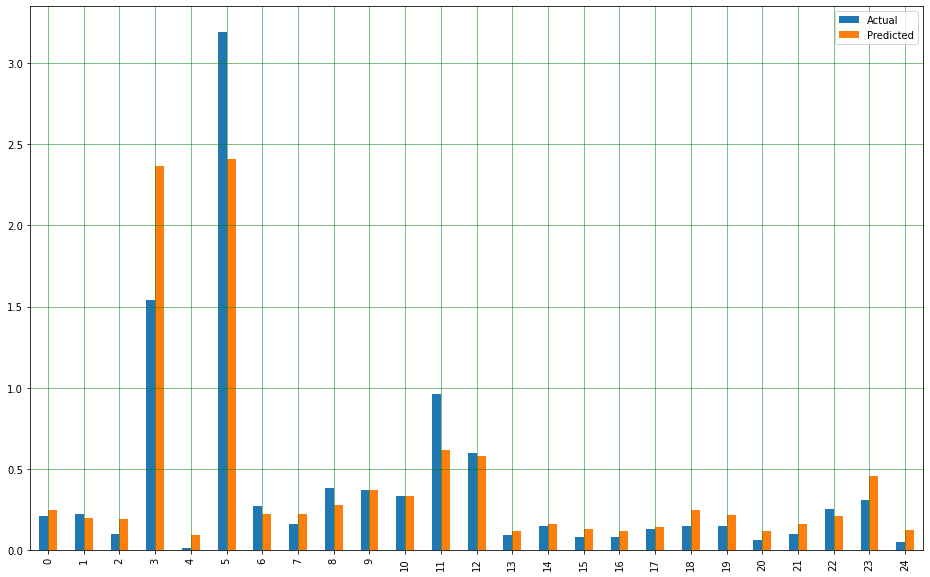

In [69]:
# comparo los resultados con los valores de testeo
# observo que los datos predecidos son bastante similares a los reales!
df1 = df.head(25)
df1.plot(kind='bar',figsize=(16,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

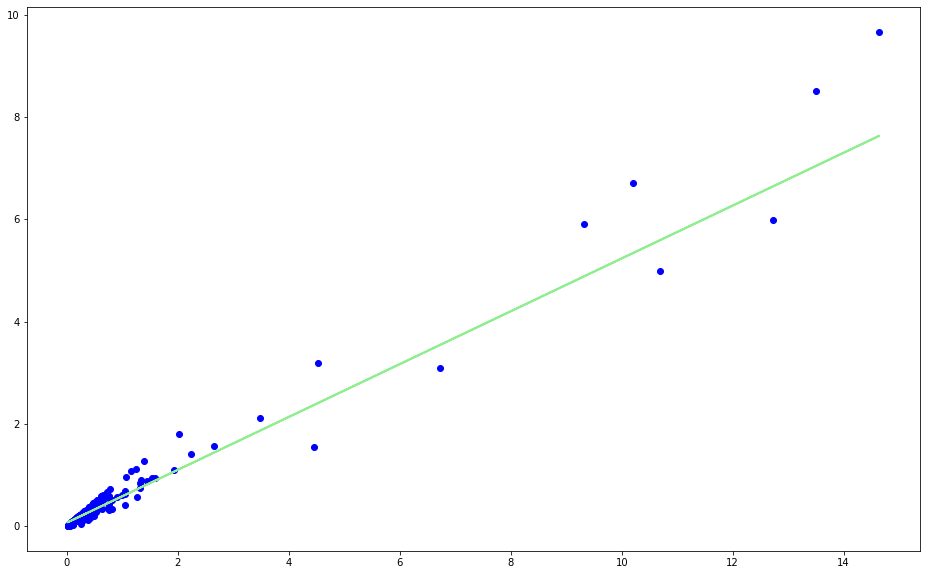

In [70]:
# imprimo el modelo
plt.rcParams['figure.figsize'] = (16.0, 10.0)
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, y_pred, color='lightgreen', linewidth=2)
plt.show()

In [71]:
# Calculo de errores
print('Error Absoluto Medio:',metrics.mean_absolute_error(y_test, y_pred)) 
print('Error Cuadratico Medio:', metrics.mean_squared_error(y_test, y_pred)) 
print('Raíz del error cuadrático medio:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Error Absoluto Medio: 0.12360069041586806
Error Cuadratico Medio: 0.07826942470768522
Raíz del error cuadrático medio: 0.27976673266792323


In [72]:
# Conclusion
# Si bien me hubiera gustado que mi modelo sea mas acertado creo que puedo visualizar lo que me habia planteado y lo que vi al 
# observar los datos en el archivo: que las ventas en NA represtaban aproximadamente la mitad de las ventas globales
# ya que en EEUU tienen el mayor consumo de videojuegos
# puedo ver en la recta del modelo que a mayor venta en Norteamerica mayor sera la venta global 
# creo que igualmente si bien podria haber elegido otros datos para analizar, pude implementar las funciones y
# herramientas para analizar datos y sacar conclusiones
